In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.utils import shuffle
from tqdm import tqdm
import time

from google.colab import drive
drive.mount('/content/drive')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/attack-free-1.csv', delimiter=',')
df['datetime'] = df['timestamp']
df['arbitration_id'] = df['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['data_field'] = df['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['attack'] = 0
df = df.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dg = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/standstill-1.csv', delimiter=',')
dg['datetime'] = dg['timestamp']
dg['arbitration_id'] = dg['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['data_field'] = dg['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['attack'] = 1
dg = dg.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

data = pd.concat([df, dg])
data = shuffle(data)

# Feature and label extraction
X = data[['datetime','arbitration_id', 'data_field']]
y = data['attack']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training with hidden_layers=(50,) and learning_rate=0.01


Epoch 1/50: 100%|██████████| 1251/1251 [00:03<00:00, 393.89it/s]


Epoch [1/50], Train Loss: 0.6920, Val Loss: 0.6883


Epoch 2/50: 100%|██████████| 1251/1251 [00:02<00:00, 513.06it/s]


Epoch [2/50], Train Loss: 0.6908, Val Loss: 0.6893


...

Epoch [46/50], Train Loss: 0.6097, Val Loss: 0.5833


Epoch 47/50: 100%|██████████| 1251/1251 [00:02<00:00, 460.27it/s]


Epoch [47/50], Train Loss: 0.6095, Val Loss: 0.5843


Epoch 48/50: 100%|██████████| 1251/1251 [00:02<00:00, 458.89it/s]


Epoch [48/50], Train Loss: 0.6073, Val Loss: 0.5815
Early stopping
Best Model Parameters: {'hidden_layers': (100, 50), 'learning_rate': 0.001}
Best Accuracy: 0.6374
Training Time: 142.02 seconds
Prediction Time: 0.26 seconds
Accuracy: 0.6374
Precision: 0.6072
Recall: 0.7952
F1 Score: 0.6886
ROC AUC: 0.7270


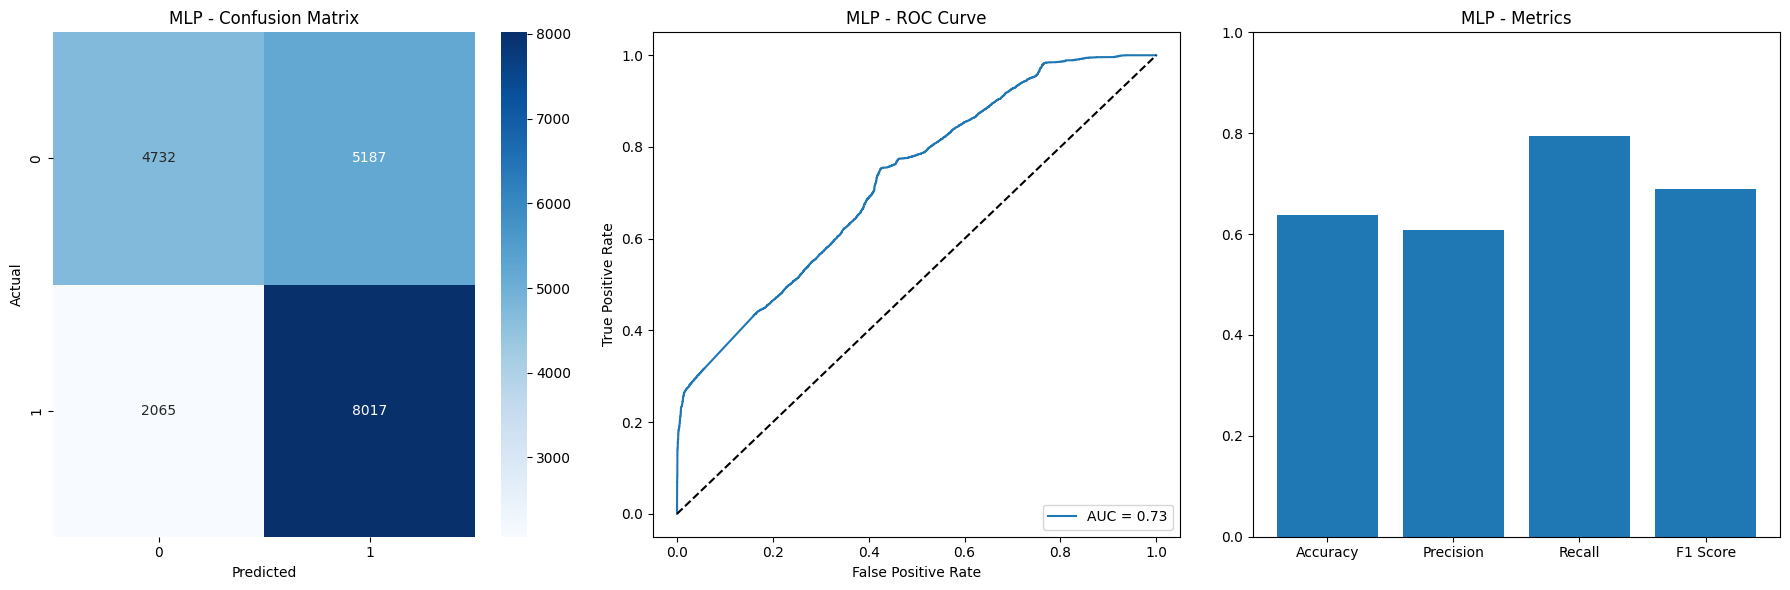

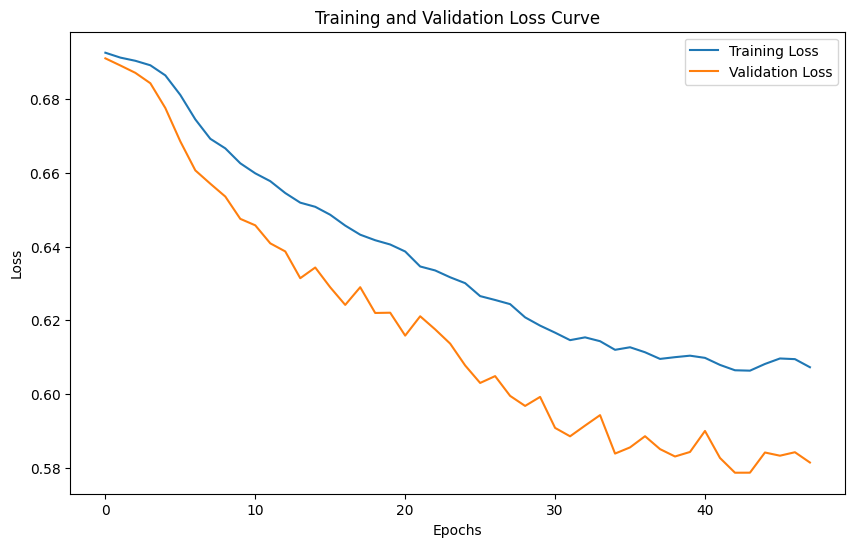

In [3]:
class CANBusDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = CANBusDataset(X_train_scaled, y_train)
test_dataset = CANBusDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes, output_size, dropout_rate=0.5):
        super(MLP, self).__init__()
        layers = []
        for size in hidden_layer_sizes:
            layers.append(nn.Linear(input_size, size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = size
        layers.append(nn.Linear(input_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def train_model(model, train_loader, criterion, optimizer, num_epochs, val_loader=None, patience=5):
    model.train()
    train_losses = []
    val_losses = []
    start_time = time.time()
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        epoch_loss = 0
        model.train()
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            labels = labels.view(outputs.shape)  # Ensure labels have the same shape as outputs
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)
        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        if val_loader:
            val_loss = 0
            model.eval()
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs).squeeze()
                    labels = labels.view(outputs.shape)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print("Early stopping")
                    model.load_state_dict(best_model_state)
                    break
        else:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    end_time = time.time()
    training_time = end_time - start_time
    return train_losses, val_losses, training_time

def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    start_time = time.time()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            preds = torch.round(torch.sigmoid(outputs))
            probs = torch.sigmoid(outputs)
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    end_time = time.time()
    prediction_time = end_time - start_time
    return np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs), prediction_time

# Hyperparameter tuning (manual tuning)
hidden_layer_sizes = [(50,), (100,), (50,50), (100,50)]
learning_rates = [0.01, 0.001]
best_model = None
best_score = 0
best_params = {}

for hidden_layers in hidden_layer_sizes:
    for lr in learning_rates:
        model = MLP(input_size=3, hidden_layer_sizes=hidden_layers, output_size=1, dropout_rate=0.5).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        print(f"Training with hidden_layers={hidden_layers} and learning_rate={lr}")
        train_losses, val_losses, training_time = train_model(model, train_loader, criterion, optimizer, num_epochs=50, val_loader=test_loader, patience=5)

        y_true, y_pred, y_prob, prediction_time = evaluate_model(model, test_loader)
        accuracy = accuracy_score(y_true, y_pred)

        if accuracy > best_score:
            best_score = accuracy
            best_model = model
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_params = {'hidden_layers': hidden_layers, 'learning_rate': lr}
            best_training_time = training_time
            best_prediction_time = prediction_time

print(f"Best Model Parameters: {best_params}")
print(f"Best Accuracy: {best_score:.4f}")
print(f"Training Time: {best_training_time:.2f} seconds")
print(f"Prediction Time: {best_prediction_time:.2f} seconds")

# Evaluate the best model
y_true, y_pred, y_prob, _ = evaluate_model(best_model, test_loader)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot confusion matrix and ROC curve
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('MLP - Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('MLP - ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right')

# Bar plot for metrics
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
ax[2].bar(metrics.keys(), metrics.values())
ax[2].set_ylim(0, 1)
ax[2].set_title('MLP - Metrics')

plt.tight_layout()
plt.show()

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(best_train_losses, label='Training Loss')
plt.plot(best_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.show()
